# Edge-Preserving Filters Demonstration

This notebook demonstrates different edge-preserving filters on the blobs.tif sample image. We will compare the following filters:
- Median filter
- Bilateral filter
- Kuwahara filter

Edge-preserving filters are useful for noise reduction while maintaining important structural features like edges and boundaries in images.

In [1]:
import numpy as np
import stackview
from skimage import filters, io
import ipywidgets as widgets
from IPython.display import display
from gpu_image_pro import bilateral, kuwahara
from pyclesperanto_prototype import median_box

## Load Sample Image

We load the blobs.tif sample image which contains circular blob-like structures that are ideal for demonstrating edge-preserving filtering.

[[ 40  32  24 ... 216 200 200]
 [ 56  40  24 ... 232 216 216]
 [ 64  48  24 ... 240 232 232]
 ...
 [ 72  80  80 ...  48  48  48]
 [ 80  80  80 ...  48  48  48]
 [ 96  88  80 ...  48  48  48]]
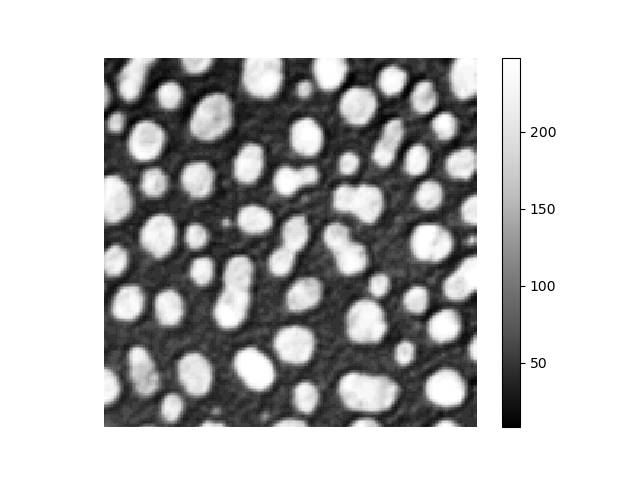
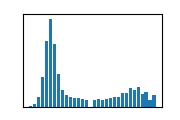

In [2]:
# Load the blobs sample image
original_image = io.imread("../../data/blobs.tif")

stackview.insight(original_image)

## Apply Median Filter

The median filter replaces each pixel with the median value of its neighborhood. It's particularly effective at removing salt-and-pepper noise while preserving edges.

[[ 40.  40.  32. ... 232. 232. 232.]
 [ 40.  40.  32. ... 232. 232. 232.]
 [ 40.  40.  32. ... 232. 232. 232.]
 ...
 [ 72.  72.  72. ...  48.  48.  48.]
 [ 72.  72.  72. ...  48.  48.  48.]
 [ 80.  72.  72. ...  48.  48.  48.]]
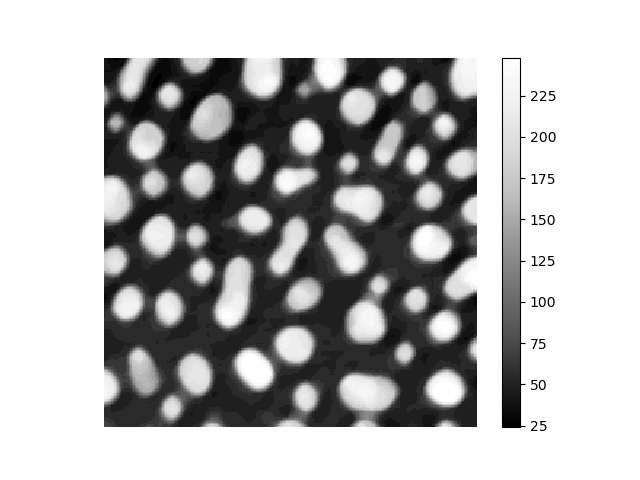
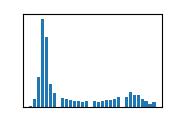

In [3]:
median_filtered_5 = median_box(original_image, radius_x=5, radius_y=5)

stackview.insight(median_filtered_5)

## Apply Bilateral Filter

The bilateral filter reduces noise while preserving edges by considering both spatial distance and intensity difference between pixels.

[[ 40  31  24 ... 216 200 200]
 [ 56  40  24 ... 232 216 216]
 [ 64  47  24 ... 240 232 232]
 ...
 [ 72  80  80 ...  48  48  48]
 [ 79  80  80 ...  48  48  47]
 [ 96  88  80 ...  48  48  47]]
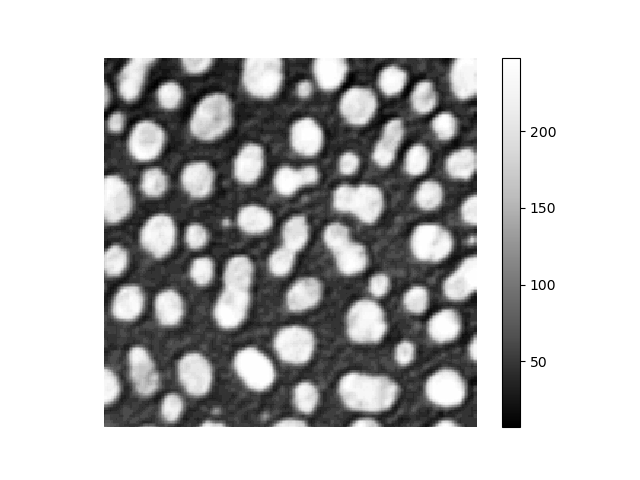
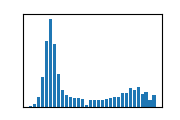

In [4]:
bilateral(original_image, sigma_color=0.2, sigma_spatial=2)

## Apply Kuwahara Filter

The Kuwahara filter creates an artistic painterly effect while preserving edges by selecting the region with minimum variance in the neighborhood.

[[ 39  32  24 ... 218 199 199]
 [ 53  38  24 ... 233 218 216]
 [ 57  44  27 ... 239 232 232]
 ...
 [ 72  79  79 ...  47  47  47]
 [ 79  80  79 ...  47  47  47]
 [ 96  86  80 ...  47  47  47]]
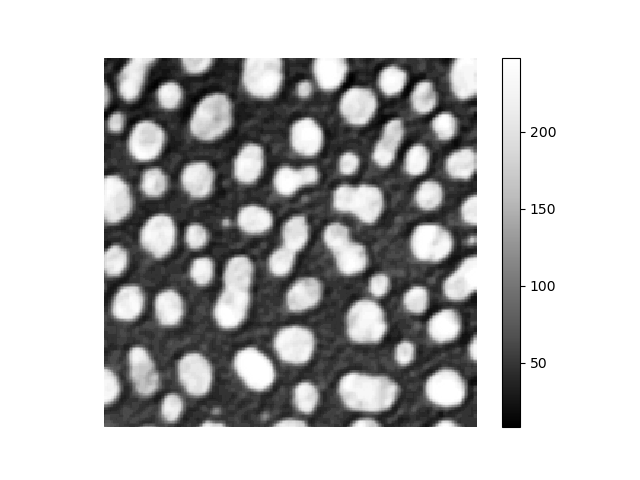
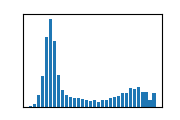

In [5]:
kuwahara(original_image, kernel_size=5)

## Interactive User Interface

In [6]:
import warnings
def median_filter(image, radius):
    return median_box(image, radius_x=radius, radius_y=radius)
    
stackview.interact(median_filter, original_image)

In [7]:
stackview.interact(bilateral, original_image)

In [8]:
stackview.interact(kuwahara, original_image)

# Exercise
Play with the percentile filter, e.g. using paramerter `percentile=50`. Is it an edge-preserving filter, too?

In [ ]:
from scipy.ndimage import percentile_filter
